In [3]:
# %pip install plotly.express
# %pip install seaborn
# %pip install matplotlib
# %pip install pandas

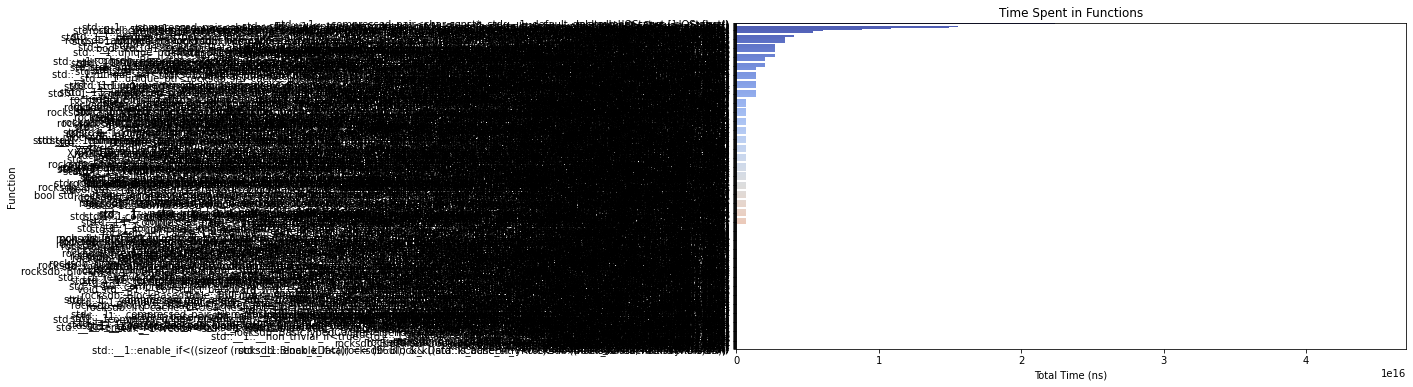

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
file_path = "dtrace.txt"

data = []
with open(file_path, "r") as file:
  for i, line in enumerate(file):
      # Split each line by the | separator
      parts = line.strip().split("|")
      if parts[0] == "ENTRY":
          data.append({"Type": "ENTRY", "Function": parts[1], "Time": "0"})
      elif parts[0] == "RETURN":
          data.append({"Type": "RETURN", "Function": parts[1], "Time": str(parts[2])})

df = pd.DataFrame(data)
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')  # Convert time to float

# # Filter relevant entries
entry_index = df[(df["Type"] == "ENTRY") & (df["Function"].str.startswith("rocksdb::DBImpl::Get("))].index[0]
return_index = df[(df["Type"] == "RETURN") & (df["Function"].str.startswith("rocksdb::DBImpl::Get("))].index[0]
df = df.loc[entry_index:return_index]

# Aggregate time spent per function
time_spent = df[df["Type"] == "RETURN"].groupby("Function")["Time"].sum().reset_index()
time_spent = time_spent.sort_values(by="Time", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Time", y="Function", data=time_spent, palette="coolwarm")
plt.xlabel("Total Time (ns)")
plt.ylabel("Function")
plt.title("Time Spent in Functions")
plt.show()
